# Week-25

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs
Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

df_runs shape:
(104400, 11)

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

Validation-row count per CvK:
CvK
3     17400
5     29000
10    58000
dtype: int64

Expected validation-row count per CvK:
290 food webs x 20 repetitions = 5800

Repeated-validation count per food web and CvK:
     count   mean  std    min    25%    50%    75%    max
CvK                                                      
3    290.0   60.0  0.0   60.0   60.0   60.0   60.0   60.0
5    290.0  100.0  0.0  100.0  100.0  100.0  100.0  100.0
10   290.0  200.0  0.0  200.0  200.0  200.0  200.0  200.0

[CHECK] CvK=3: found 17400 rows, expected 5800. This may indicate missing food webs, fewer/more repetitions, or that each

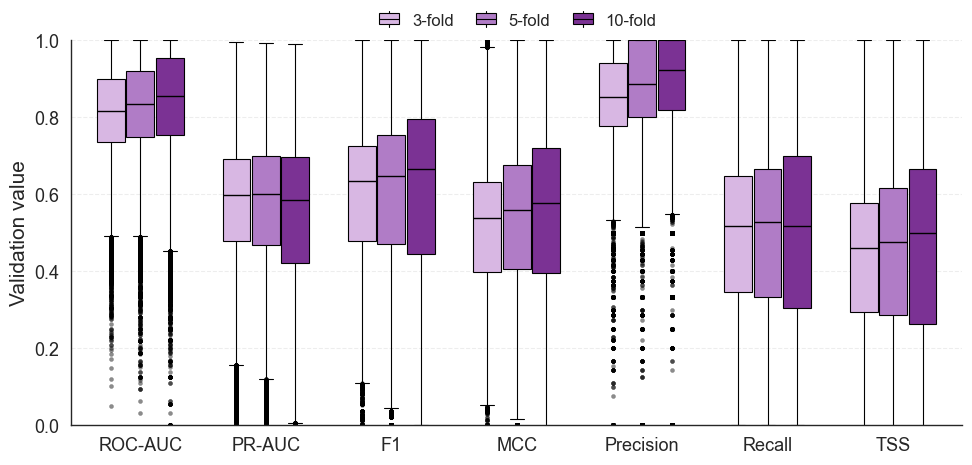

In [35]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR_REL = Path(
    "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
)

PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

EXPECTED_FOODWEBS = 290
EXPECTED_REPEATS = 20
EXPECTED_POINTS_PER_CVK = EXPECTED_FOODWEBS * EXPECTED_REPEATS

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]


def resolve_log_dir(rel_path: Path) -> Path:
    rel_path = Path(rel_path)

    if rel_path.is_absolute():
        return rel_path

    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / rel_path
        if candidate.is_dir():
            return candidate.resolve()

    return (Path.cwd() / rel_path).resolve()


LOG_DIR = resolve_log_dir(LOG_DIR_REL)


def cvk_label(k: int) -> str:
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing


def collect_foodweb_validation_runs(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = [
        "CvK",
        "CvK_label",
        "Foodweb",
        "RunIndexWithinFoodwebCvK",
        *METRICS,
    ]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"Using LOG_DIR: {log_dir}")
    print(f"Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)

        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            df = df[df["K"] == K_TARGET].copy()

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            print(f"[SKIP] {Path(csv_path).name} no rows after K/CvK filtering.")
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)

        rows.append(df[["CvK", "Foodweb", *METRICS]])

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    out["RunIndexWithinFoodwebCvK"] = (
        out.groupby(["Foodweb", "CvK"]).cumcount() + 1
    )

    return out[expected_cols]


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans,
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_validation_runs_boxplots(df_runs: pd.DataFrame) -> None:
    if df_runs.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_runs["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(11.5, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_runs.loc[df_runs["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=3,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.45,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel("Validation value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=1.2,
    )

    # plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# -----------------------------
# Run
# -----------------------------
df_runs = collect_foodweb_validation_runs(LOG_DIR, PATTERN)

print("\ndf_runs shape:")
print(df_runs.shape)

if df_runs.empty:
    print(
        "\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, "
        "CvK values, and skipped-file messages above."
    )
else:
    print("\nFoodweb count per CvK:")
    print(df_runs.groupby("CvK")["Foodweb"].nunique())

    print("\nValidation-row count per CvK:")
    row_counts = df_runs.groupby("CvK").size()
    print(row_counts)

    print("\nExpected validation-row count per CvK:")
    print(
        f"{EXPECTED_FOODWEBS} food webs x {EXPECTED_REPEATS} repetitions "
        f"= {EXPECTED_POINTS_PER_CVK}"
    )

    print("\nRepeated-validation count per food web and CvK:")
    repeat_summary = (
        df_runs.groupby(["CvK", "Foodweb"])
        .size()
        .groupby("CvK")
        .describe()
    )
    print(repeat_summary)

    for cvk, count in row_counts.items():
        if count != EXPECTED_POINTS_PER_CVK:
            print(
                f"\n[CHECK] CvK={cvk}: found {count} rows, "
                f"expected {EXPECTED_POINTS_PER_CVK}. "
                "This may indicate missing food webs, fewer/more repetitions, "
                "or that each CSV row does not correspond exactly to one repeated validation."
            )

    plot_validation_runs_boxplots(df_runs)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_74340/353091667.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


Filtered results by TrainRatio: kept only TrainRatio = 90.

=== Raw validation-row count before metadata merge ===
Rows after TrainRatio filtering: 5800
Expected rows: 290 food webs x 20 repetitions = 5800

Repeated-validation rows per food web before metadata merge:
count    290.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
dtype: float64

Unique Iteration values per food web:
count    290.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: Iteration, dtype: float64

Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

=== Validation-row count after metadata merge and node filtering ===
Rows available for plotting: 5800

=== Precision median and variance by ecosystem using all validation rows ===
          EcosystemType  n_foodwebs  n_validation_values  Precision_Median  Precision_Variance
                  lakes          55                 1100            1.0

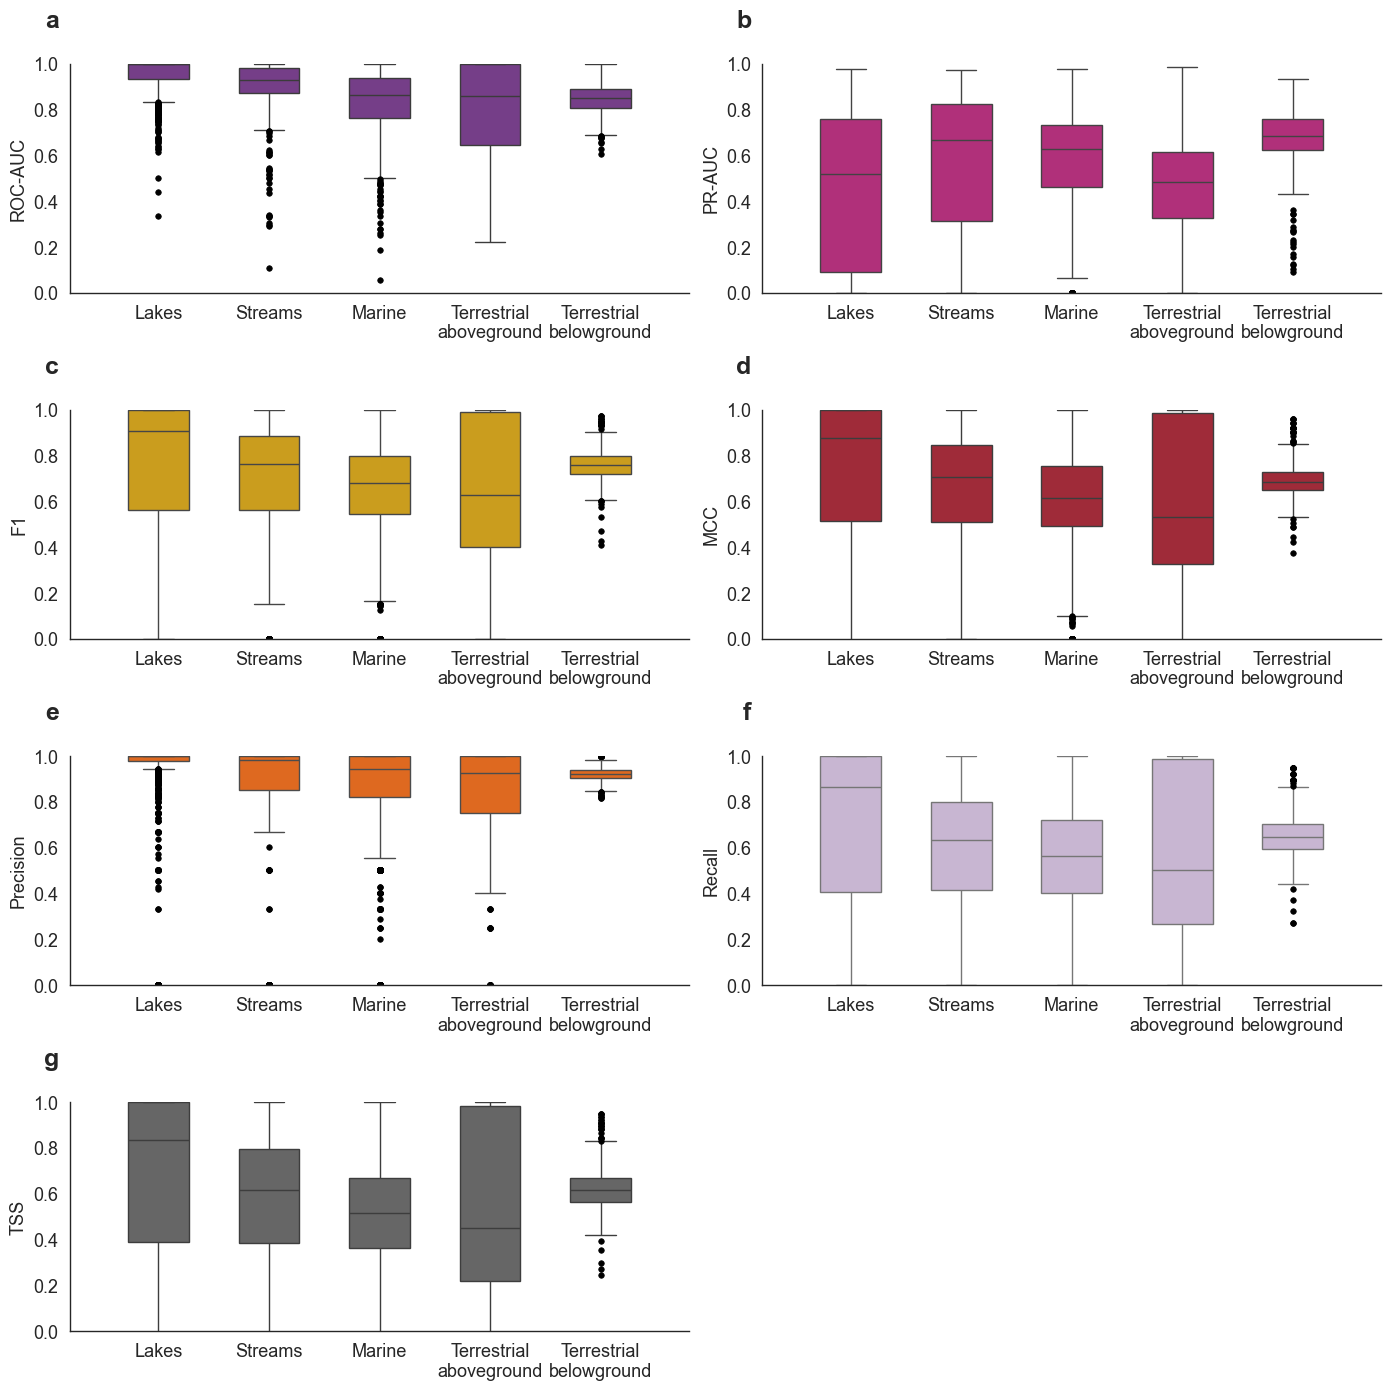

In [37]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

# === Config ===
METRIC_ORDER = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

xtick_labels = [
    "ROC-AUC",
    "PR-AUC",
    "F1",
    "MCC",
    "Precision",
    "Recall",
    "TSS",
]

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

EXPECTED_FOODWEBS = 290
EXPECTED_REPEATS = 20
EXPECTED_POINTS_PER_METRIC = EXPECTED_FOODWEBS * EXPECTED_REPEATS

Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",     # purple
    "PR_AUC": "#C51B7D",      # magenta
    "F1Score": "#E6AB02",     # mustard
    "TestMCC": "#B2182B",     # deep red / burgundy
    "Precision": "#FE6100",   # orange
    "Recall": "#CAB2D6",      # violet
    "TestTSS": "#666666",     # dark gray
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}


# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)


def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one, e.g. 'S', 'nodes', 'num_species', or 'node_count'."
    )


# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)


# === Validate required columns ===
required_cols = [TRAIN_RATIO_COL, "Foodweb", *METRIC_ORDER]

missing_required_cols = [col for col in required_cols if col not in df_all.columns]

if missing_required_cols:
    raise RuntimeError(
        f"The following required columns are missing from result CSVs: {missing_required_cols}"
    )

if "Foodweb" not in df_ecosystem.columns:
    raise RuntimeError("Column 'Foodweb' not found in ecosystem metadata.")

if "EcosystemType" not in df_ecosystem.columns:
    raise RuntimeError("Column 'EcosystemType' not found in ecosystem metadata.")


# === Filter target TrainRatio ===
df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")


# === Keep every validation row as one data point ===
# No groupby mean is applied here.
# Therefore, if each food web has 20 validation rows, each metric has 290 x 20 = 5800 values.

print("\n=== Raw validation-row count before metadata merge ===")
print(f"Rows after TrainRatio filtering: {len(df_all)}")
print(f"Expected rows: {EXPECTED_FOODWEBS} food webs x {EXPECTED_REPEATS} repetitions = {EXPECTED_POINTS_PER_METRIC}")

if "Iteration" in df_all.columns:
    repeat_summary_before_merge = (
        df_all.groupby("Foodweb")
        .size()
        .describe()
    )

    print("\nRepeated-validation rows per food web before metadata merge:")
    print(repeat_summary_before_merge)

    iteration_count_summary = (
        df_all.groupby("Foodweb")["Iteration"]
        .nunique()
        .describe()
    )

    print("\nUnique Iteration values per food web:")
    print(iteration_count_summary)


# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left",
)


# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"\nFiltered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

print("\n=== Validation-row count after metadata merge and node filtering ===")
print(f"Rows available for plotting: {len(df_merged)}")

if len(df_merged) != EXPECTED_POINTS_PER_METRIC:
    print(
        f"[CHECK] Found {len(df_merged)} rows after filtering, "
        f"but expected {EXPECTED_POINTS_PER_METRIC}. "
        "This may indicate missing food webs, missing metadata, fewer/more iterations, "
        "or duplicated rows introduced during the metadata merge."
    )


# ============================================================
# Precision median by ecosystem: all validation rows
# ============================================================

if "Precision" not in df_merged.columns:
    raise RuntimeError("Column 'Precision' not found in df_merged.")

precision_summary = (
    df_merged
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        n_validation_values=("Precision", "size"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Precision median and variance by ecosystem using all validation rows ===")
print(precision_summary.to_string(index=False))

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]

lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")

print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']})"
)

print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']})"
)

print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']})"
)

print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']})"
)


# === Prepare long-format data ===
id_vars = ["Foodweb", TRAIN_RATIO_COL, "EcosystemType"]

if "Iteration" in df_merged.columns:
    id_vars.append("Iteration")

df_plot = df_merged.melt(
    id_vars=id_vars,
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

df_plot[TRAIN_RATIO_COL] = df_plot[TRAIN_RATIO_COL].astype(str)

df_plot["Metric"] = pd.Categorical(
    df_plot["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

print("\n=== Non-missing values per metric after melting ===")
metric_counts = (
    df_plot
    .dropna(subset=["Value"])
    .groupby("Metric", observed=True)
    .size()
)

print(metric_counts)

for metric, count in metric_counts.items():
    if count != EXPECTED_POINTS_PER_METRIC:
        print(
            f"[CHECK] Metric {metric}: found {count} non-missing values, "
            f"expected {EXPECTED_POINTS_PER_METRIC}."
        )


# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]


# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)


def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}"


labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}


# === Data already filtered to target TrainRatio ===
subset = df_plot.copy()


# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()

    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)

    ax.set_ylim(0, 1.0)

    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )


# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)
plt.show()

[INFO] Loaded paired input: 23,196 web x run x metric rows
[INFO] Loaded paired tests: 20 rows
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/run_level_boxplots_paired_p_delta_train90.png


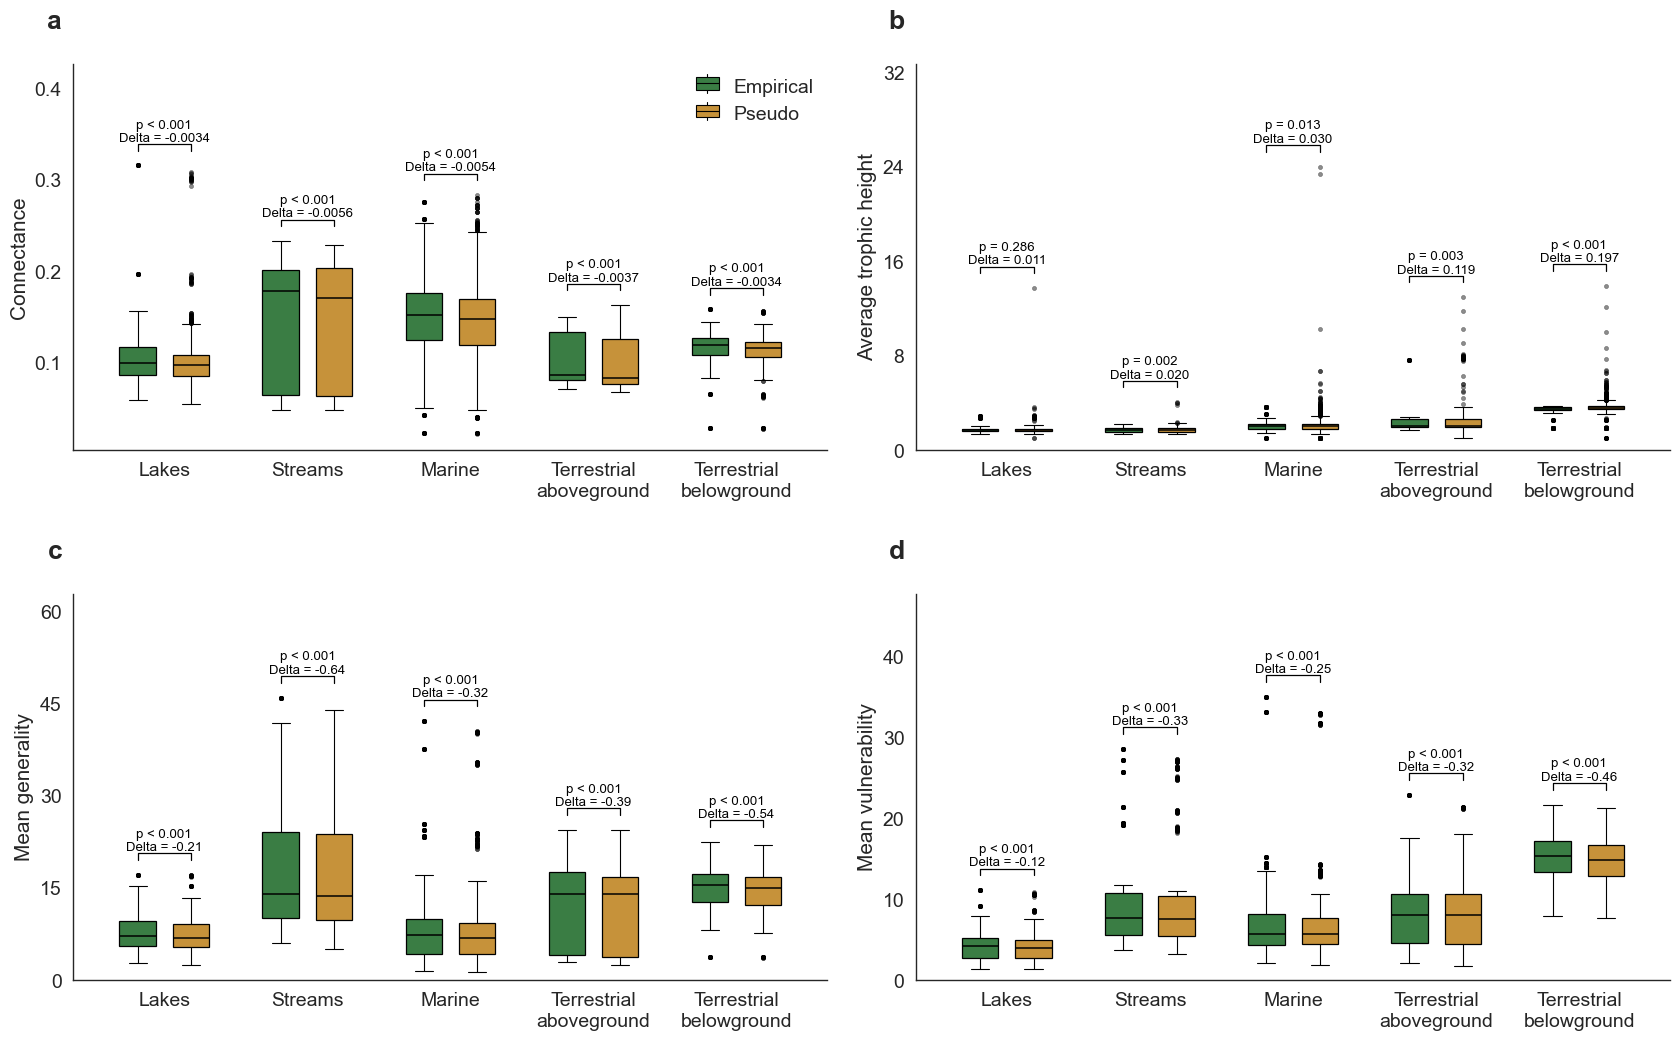

In [17]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

PAIRED_INPUT = EOIN_DIR / "eoin_paired_input_train90.csv"
PAIRED_TESTS = EOIN_DIR / "eoin_paired_ttest_by_ecosystem_results_train90.csv"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

def format_p_delta(p_value, mean_delta, metric):
    if pd.isna(p_value):
        p_label = "p = n/a"
    elif p_value < 0.001:
        p_label = "p < 0.001"
    else:
        p_label = f"p = {p_value:.3f}"

    if pd.isna(mean_delta):
        delta_label = "Delta = n/a"
    elif metric == "connectance":
        delta_label = f"Delta = {mean_delta:.4f}"
    elif metric == "average_trophic_height":
        delta_label = f"Delta = {mean_delta:.3f}"
    else:
        delta_label = f"Delta = {mean_delta:.2f}"

    return f"{p_label}\n{delta_label}"

def add_ttest_bracket(ax, x1, x2, y, h, label):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=0.9,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        label,
        ha="center",
        va="bottom",
        fontsize=9.5,
        linespacing=1.15,
        color="black",
        clip_on=False,
    )

def draw_box(ax, values, position, facecolor):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# LOAD CORRECTED RUN-LEVEL DATA
# ============================================================
paired_input = pd.read_csv(PAIRED_INPUT)
paired_tests = pd.read_csv(PAIRED_TESTS)

paired_input["metric"] = paired_input["metric"].astype(str)
paired_input["ecosystem"] = paired_input["ecosystem"].astype(str)

for col in ["real", "pseudo"]:
    paired_input[col] = pd.to_numeric(paired_input[col], errors="coerce")

paired_tests["metric"] = paired_tests["metric"].astype(str)
paired_tests["ecosystem"] = paired_tests["ecosystem"].astype(str)
paired_tests["p_value"] = pd.to_numeric(paired_tests["p_value"], errors="coerce")
paired_tests["delta_pseudo_minus_real"] = pd.to_numeric(
    paired_tests["delta_pseudo_minus_real"],
    errors="coerce",
)

print(f"[INFO] Loaded paired input: {len(paired_input):,} web x run x metric rows")
print(f"[INFO] Loaded paired tests: {len(paired_tests):,} rows")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = paired_input[paired_input["metric"] == metric].copy()
    panel_df = panel_df.dropna(subset=["real", "pseudo", "ecosystem"])

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    bracket_specs = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        real_values = pd.to_numeric(eco_df["real"], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df["pseudo"], errors="coerce").dropna().values

        if len(real_values):
            draw_box(
                ax=ax,
                values=real_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            all_values.extend(real_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
            )
            all_values.extend(pseudo_values)

        pair_values = np.concatenate([real_values, pseudo_values])
        if len(pair_values):
            test_row = paired_tests[
                (paired_tests["metric"] == metric)
                & (paired_tests["ecosystem"] == eco)
            ].iloc[0]

            label = format_p_delta(
                p_value=test_row["p_value"],
                mean_delta=test_row["delta_pseudo_minus_real"],
                metric=metric,
            )

            bracket_specs.append((base_x, np.nanmax(pair_values), label))

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    # Independent y-axis zoom per panel, with extra headroom for brackets
    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        data_range = local_max - local_min if local_max > local_min else 0.05

        local_min = max(0.0, local_min - 0.06 * data_range)
        local_max = local_max + 0.38 * data_range

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        bracket_h = 0.025 * data_range
        bracket_pad = 0.055 * data_range

        for base_x, pair_max, p_label in bracket_specs:
            add_ttest_bracket(
                ax=ax,
                x1=base_x - TYPE_OFFSET,
                x2=base_x + TYPE_OFFSET,
                y=pair_max + bracket_pad,
                h=bracket_h,
                label=p_label,
            )

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

    if idx == 0:
        ax.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={dict: HandlerMiniBoxplot()},
            loc="upper right",
            ncol=1,
            frameon=False,
            fontsize=14,
            handlelength=1.5,
            handleheight=0.9,
            handletextpad=0.6,
            borderpad=0.2,
            labelspacing=0.45,
        )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=2.6)

OUT_PATH = EOIN_DIR / "run_level_boxplots_paired_p_delta_train90.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Loaded paired input: 23,145 web x run x metric rows
[INFO] Loaded paired tests: 20 rows
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60/run_level_boxplots_paired_p_delta_train60.png


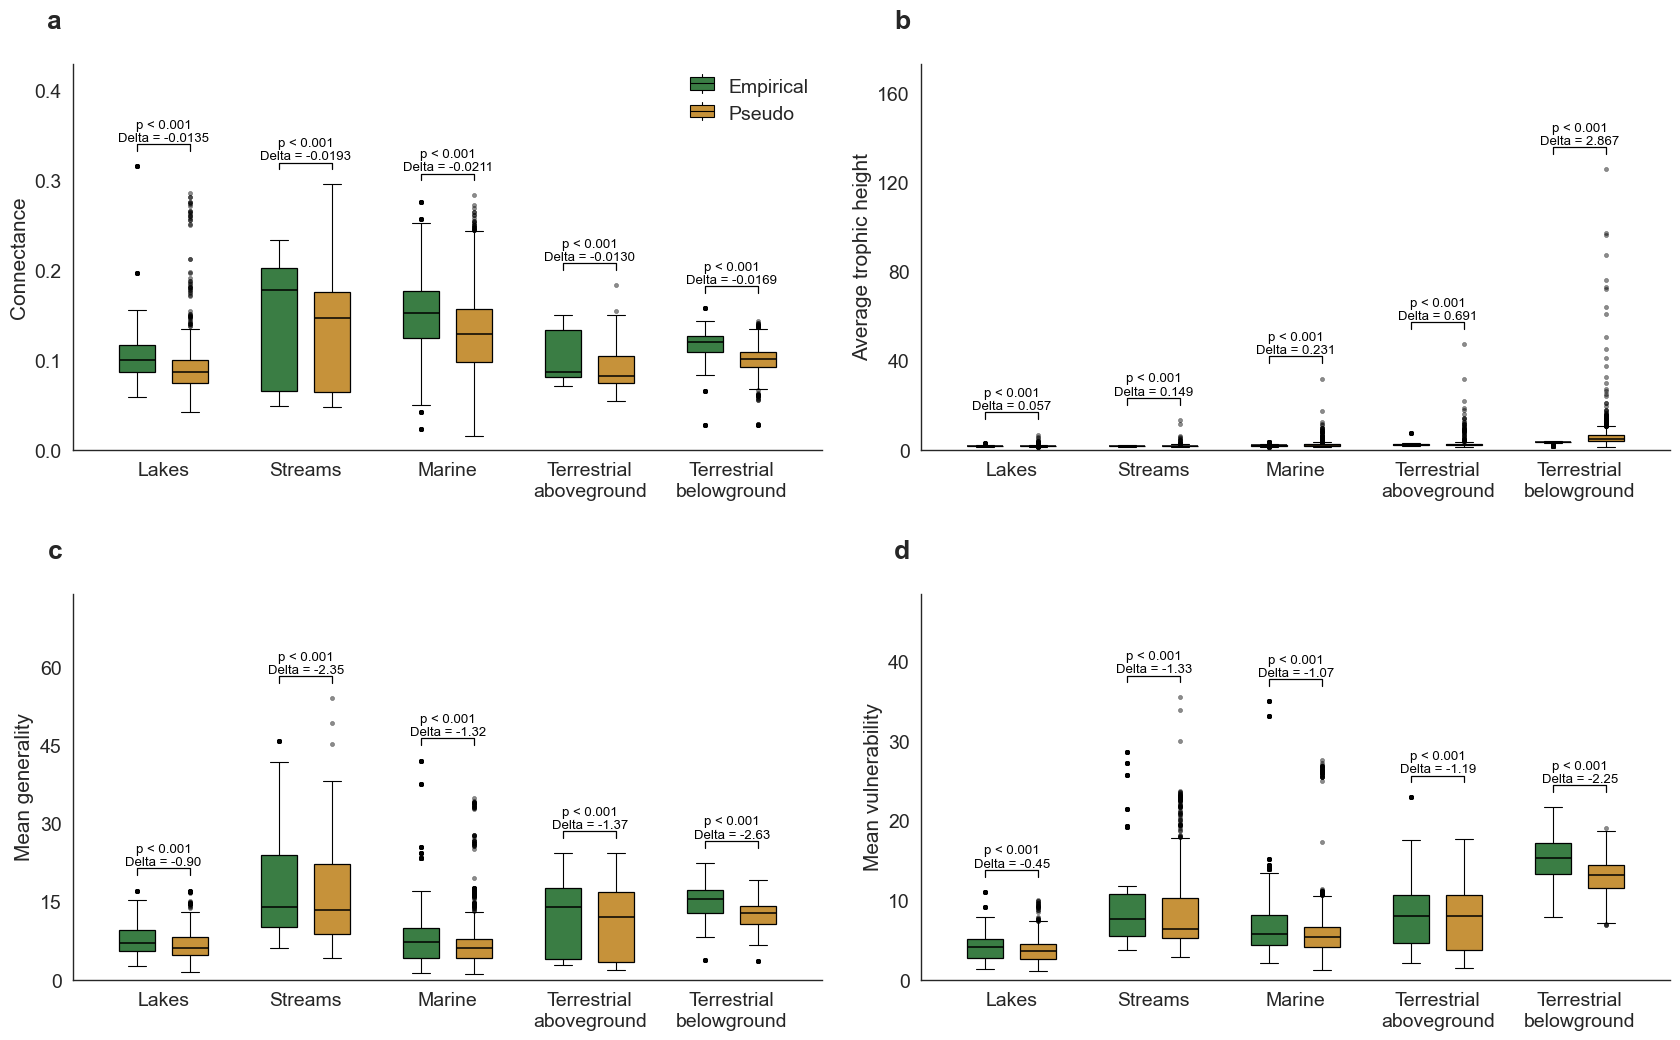

In [25]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

PAIRED_INPUT = EOIN_DIR / f"eoin_paired_input_train{TRAIN_RATIO}.csv"
PAIRED_TESTS = EOIN_DIR / f"eoin_paired_ttest_by_ecosystem_results_train{TRAIN_RATIO}.csv"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

def format_p_delta(p_value, mean_delta, metric):
    if pd.isna(p_value):
        p_label = "p = n/a"
    elif p_value < 0.001:
        p_label = "p < 0.001"
    else:
        p_label = f"p = {p_value:.3f}"

    if pd.isna(mean_delta):
        delta_label = "Delta = n/a"
    elif metric == "connectance":
        delta_label = f"Delta = {mean_delta:.4f}"
    elif metric == "average_trophic_height":
        delta_label = f"Delta = {mean_delta:.3f}"
    else:
        delta_label = f"Delta = {mean_delta:.2f}"

    return f"{p_label}\n{delta_label}"

def add_ttest_bracket(ax, x1, x2, y, h, label):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        linewidth=0.9,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        label,
        ha="center",
        va="bottom",
        fontsize=9.5,
        linespacing=1.15,
        color="black",
        clip_on=False,
    )

def draw_box(ax, values, position, facecolor):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# LOAD CORRECTED RUN-LEVEL DATA
# ============================================================
paired_input = pd.read_csv(PAIRED_INPUT)
paired_tests = pd.read_csv(PAIRED_TESTS)

paired_input["metric"] = paired_input["metric"].astype(str)
paired_input["ecosystem"] = paired_input["ecosystem"].astype(str)

for col in ["real", "pseudo"]:
    paired_input[col] = pd.to_numeric(paired_input[col], errors="coerce")

paired_tests["metric"] = paired_tests["metric"].astype(str)
paired_tests["ecosystem"] = paired_tests["ecosystem"].astype(str)
paired_tests["p_value"] = pd.to_numeric(paired_tests["p_value"], errors="coerce")
paired_tests["delta_pseudo_minus_real"] = pd.to_numeric(
    paired_tests["delta_pseudo_minus_real"],
    errors="coerce",
)

print(f"[INFO] Loaded paired input: {len(paired_input):,} web x run x metric rows")
print(f"[INFO] Loaded paired tests: {len(paired_tests):,} rows")

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = paired_input[paired_input["metric"] == metric].copy()
    panel_df = panel_df.dropna(subset=["real", "pseudo", "ecosystem"])

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING

    all_values = []
    bracket_specs = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        real_values = pd.to_numeric(eco_df["real"], errors="coerce").dropna().values
        pseudo_values = pd.to_numeric(eco_df["pseudo"], errors="coerce").dropna().values

        if len(real_values):
            draw_box(
                ax=ax,
                values=real_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
            )
            all_values.extend(real_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Pseudo"],
            )
            all_values.extend(pseudo_values)

        pair_values = np.concatenate([real_values, pseudo_values])
        if len(pair_values):
            test_row = paired_tests[
                (paired_tests["metric"] == metric)
                & (paired_tests["ecosystem"] == eco)
            ].iloc[0]

            label = format_p_delta(
                p_value=test_row["p_value"],
                mean_delta=test_row["delta_pseudo_minus_real"],
                metric=metric,
            )

            bracket_specs.append((base_x, np.nanmax(pair_values), label))

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    panel_vals = np.asarray(all_values, dtype=float)
    panel_vals = panel_vals[np.isfinite(panel_vals)]

    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        data_range = local_max - local_min if local_max > local_min else 0.05

        local_min = max(0.0, local_min - 0.06 * data_range)
        local_max = local_max + 0.38 * data_range

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        bracket_h = 0.025 * data_range
        bracket_pad = 0.055 * data_range

        for base_x, pair_max, p_label in bracket_specs:
            add_ttest_bracket(
                ax=ax,
                x1=base_x - TYPE_OFFSET,
                x2=base_x + TYPE_OFFSET,
                y=pair_max + bracket_pad,
                h=bracket_h,
                label=p_label,
            )

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

    if idx == 0:
        ax.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={dict: HandlerMiniBoxplot()},
            loc="upper right",
            ncol=1,
            frameon=False,
            fontsize=14,
            handlelength=1.5,
            handleheight=0.9,
            handletextpad=0.6,
            borderpad=0.2,
            labelspacing=0.45,
        )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=2.6)

OUT_PATH = EOIN_DIR / f"run_level_boxplots_paired_p_delta_train{TRAIN_RATIO}.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

In [15]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ------------------------------------------------------------
# Locate repo root robustly
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

print("Loading Eoin/Athen statistical outputs from:")
print(EOIN_DIR)

# ------------------------------------------------------------
# Load corrected run-level tables
# ------------------------------------------------------------
run_summary = pd.read_csv(EOIN_DIR / "eoin_run_summary_train90.csv")

connectance_paired_input = pd.read_csv(EOIN_DIR / "eoin_connectance_paired_input_train90.csv")
paired_input = pd.read_csv(EOIN_DIR / "eoin_paired_input_train90.csv")

mixed_model_wide = pd.read_csv(EOIN_DIR / "eoin_mixed_model_wide_train90.csv")
mixed_model_long = pd.read_csv(EOIN_DIR / "eoin_mixed_model_long_train90.csv")

paired_general = pd.read_csv(EOIN_DIR / "eoin_paired_ttest_general_results_train90.csv")
paired_by_ecosystem = pd.read_csv(EOIN_DIR / "eoin_paired_ttest_by_ecosystem_results_train90.csv")

r_paired_general_path = EOIN_DIR / "eoin_r_paired_ttest_general_results_train90.csv"
r_lme_anova_path = EOIN_DIR / "eoin_r_lme_anova_train90.csv"
r_lme_coef_path = EOIN_DIR / "eoin_r_lme_coefficients_train90.csv"
r_lme_posthoc_path = EOIN_DIR / "eoin_r_lme_posthoc_webtype_by_ecosystem_train90.csv"

r_paired_general = pd.read_csv(r_paired_general_path) if r_paired_general_path.exists() else None
r_lme_anova = pd.read_csv(r_lme_anova_path) if r_lme_anova_path.exists() else None
r_lme_coef = pd.read_csv(r_lme_coef_path) if r_lme_coef_path.exists() else None
r_lme_posthoc = pd.read_csv(r_lme_posthoc_path) if r_lme_posthoc_path.exists() else None

# ------------------------------------------------------------
# Formatting helpers
# ------------------------------------------------------------
def format_p(p):
    if pd.isna(p):
        return "n/a"
    p = float(p)
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

def show_rows(df):
    return f"{len(df):,} rows x {len(df.columns):,} columns"

def style_paired_table(df):
    preferred_cols = [
        "metric", "scope", "ecosystem",
        "n_pairs", "n_webs",
        "mean_real", "mean_pseudo",
        "delta_pseudo_minus_real",
        "std_delta", "t_statistic", "df",
        "p_value", "alpha", "reject_h0", "direction",
        "conf_low", "conf_high",
    ]

    show = df[[c for c in preferred_cols if c in df.columns]].copy()

    if "p_value" in show.columns:
        show["p_label"] = show["p_value"].apply(format_p)

    formatters = {
        "mean_real": "{:.4f}",
        "mean_pseudo": "{:.4f}",
        "delta_pseudo_minus_real": "{:.4f}",
        "std_delta": "{:.4f}",
        "t_statistic": "{:.3f}",
        "p_value": "{:.3e}",
        "conf_low": "{:.4f}",
        "conf_high": "{:.4f}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "delta_pseudo_minus_real" in show.columns:
        style = style.background_gradient(
            subset=["delta_pseudo_minus_real"],
            cmap="RdBu_r"
        )

    return style

def style_lme_anova(df):
    show = df.copy()

    if "p-value" in show.columns:
        show["p_label"] = show["p-value"].apply(format_p)

    return show.style.format({
        "F-value": "{:.3f}",
        "p-value": "{:.3e}",
    })

def style_lme_posthoc(df):
    show = df.copy()

    if "p.value" in show.columns:
        show["p_label"] = show["p.value"].apply(format_p)

    formatters = {
        "estimate": "{:.4f}",
        "DeltaPseudoMinusReal": "{:.4f}",
        "SE": "{:.4f}",
        "t.ratio": "{:.3f}",
        "p.value": "{:.3e}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "DeltaPseudoMinusReal" in show.columns:
        style = style.background_gradient(
            subset=["DeltaPseudoMinusReal"],
            cmap="RdBu_r"
        )

    return style

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------
display(Markdown("## 1. Run summary"))
display(Markdown("Confirms that the analysis unit is now `web x run`, not averaged food-web means."))
display(run_summary)

display(Markdown("## 2. Paired t-test input: connectance only"))
display(Markdown(f"`{show_rows(connectance_paired_input)}`"))
display(Markdown("One row per `web x run_id`, with the empirical web paired against one generated pseudo web."))
display(connectance_paired_input.head(20))

display(Markdown("## 3. Paired t-test input: all metrics"))
display(Markdown(f"`{show_rows(paired_input)}`"))
display(Markdown("One row per `web x run_id x metric`, with `real` and `pseudo` on the same row."))
display(paired_input.head(20))

display(Markdown("## 4. Paired t-test results: general"))
display(Markdown("These are the run-level paired t-tests requested by Athen/Eoin."))
display(style_paired_table(paired_general))

display(Markdown("## 5. Paired t-test results: by ecosystem"))
display(style_paired_table(paired_by_ecosystem))

display(Markdown("## 6. Compact p-value table by ecosystem"))
p_table = paired_by_ecosystem.copy()
p_table["p_label"] = p_table["p_value"].apply(format_p)

display(
    p_table.pivot(
        index="ecosystem",
        columns="metric",
        values="p_label"
    )
)

display(Markdown("## 7. Mean Delta table by ecosystem"))
display(Markdown("`Delta = Pseudo - Real`; negative values mean pseudo webs are lower than empirical webs."))
delta_table = paired_by_ecosystem.pivot(
    index="ecosystem",
    columns="metric",
    values="delta_pseudo_minus_real"
)

display(delta_table.style.format("{:.4f}").background_gradient(cmap="RdBu_r"))

display(Markdown("## 8. Mixed-model input: wide format"))
display(Markdown(f"`{show_rows(mixed_model_wide)}`"))
display(Markdown("This follows Eoin's suggested structure: `web`, `run_id`, `web_type`, `ecosystem`, `connectance`, plus other metrics."))
display(mixed_model_wide.head(20))

display(Markdown("## 9. Mixed-model input: long format"))
display(Markdown(f"`{show_rows(mixed_model_long)}`"))
display(Markdown("This is the input used by the R script to run the same mixed-effects model for all metrics."))
display(mixed_model_long.head(20))

if r_paired_general is not None:
    display(Markdown("## 10. R paired t-test results: general"))
    display(style_paired_table(r_paired_general))
else:
    display(Markdown("## 10. R paired t-test results: general"))
    display(Markdown("R paired t-test output not found."))

if r_lme_anova is not None:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("Model: `lme(value ~ web_type * ecosystem, random = ~1 | web)`"))
    display(style_lme_anova(r_lme_anova))
else:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("R ANOVA output not found. Run `Rscript docs/stats/eoin_mixed_effects_wlnm_dir_neg_apocrita.R` first."))

if r_lme_coef is not None:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(r_lme_coef)
else:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(Markdown("R coefficient output not found."))

if r_lme_posthoc is not None:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`."))
    display(style_lme_posthoc(r_lme_posthoc))
else:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("R post-hoc output not found. Make sure `emmeans` is installed and rerun the R script."))

Loading Eoin/Athen statistical outputs from:
/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin


## 1. Run summary

Confirms that the analysis unit is now `web x run`, not averaged food-web means.

,Field,Value
0,SourceLogFiles,290
1,TotalRowsRead,52200
2,TargetTrainRatioRows,5800
3,LongRowsWritten,46396
4,MissingMetricValuesSkipped,4
5,FoodwebsMissingMetadata,0
6,MissingMetadataFoodwebs,NaN
7,AnalysisUnit,web x run
8,RunLevelPairedRows,23196
9,ConnectancePairedRows,5800


## 2. Paired t-test input: connectance only

...

## 12. R mixed-effects model: coefficients

,Metric,Coefficient,Value,Std.Error,DF,t-value,p-value
0,average_trophic_height,(Intercept),1.695778,0.068246,11297,24.847888,9.603438e-133
1,average_trophic_height,web_typepseudo,0.010974,0.017300,11297,0.634327,5.258803e-01
2,average_trophic_height,ecosystemmarine,0.308943,0.081051,285,3.811715,1.691374e-04
3,average_trophic_height,ecosystemstreams,-0.033264,0.117499,285,-0.283096,7.773085e-01
4,average_trophic_height,ecosystemterrestrial aboveground,0.705994,0.129829,285,5.437870,1.160454e-07
5,average_trophic_height,ecosystemterrestrial belowground,1.659693,0.097896,285,16.953582,4.601022e-45
6,average_trophic_height,web_typepseudo:ecosystemmarine,0.018868,0.020547,11297,0.918322,3.584697e-01
7,average_trophic_height,web_typepseudo:ecosystemstreams,0.009025,0.029777,11297,0.303073,7.618399e-01
8,average_trophic_height,web_typepseudo:ecosystemterrestrial aboveground,0.108510,0.032900,11297,3.298132,9.763130e-04
9,average_trophic_height,web_typepseudo:ecosystemterrestrial belowground,0.185682,0.024811,11297,7.484004,7.744653e-14


## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem

These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`.

,Metric,ecosystem,contrast,estimate,DeltaPseudoMinusReal,SE,df,t.ratio,p.value,Direction,p_label
0,average_trophic_height,lakes,real - pseudo,-0.0110,0.0110,0.0173,11297,-0.634,5.259e-01,pseudo_higher,p = 0.526
1,average_trophic_height,marine,real - pseudo,-0.0298,0.0298,0.0111,11297,-2.692,7.108e-03,pseudo_higher,p = 0.007
2,average_trophic_height,streams,real - pseudo,-0.0200,0.0200,0.0242,11297,-0.825,4.093e-01,pseudo_higher,p = 0.409
3,average_trophic_height,terrestrial aboveground,real - pseudo,-0.1195,0.1195,0.0280,11297,-4.270,1.974e-05,pseudo_higher,p < 0.001
4,average_trophic_height,terrestrial belowground,real - pseudo,-0.1967,0.1967,0.0178,11297,-11.058,2.799e-28,pseudo_higher,p < 0.001
5,connectance,lakes,real - pseudo,0.0034,-0.0034,0.0001,11305,30.298,6.116e-194,pseudo_lower,p < 0.001
6,connectance,marine,real - pseudo,0.0054,-0.0054,0.0001,11305,74.859,0.000e+00,pseudo_lower,p < 0.001
7,connectance,streams,real - pseudo,0.0056,-0.0056,0.0002,11305,35.649,7.084e-264,pseudo_lower,p < 0.001
8,connectance,terrestrial aboveground,real - pseudo,0.0037,-0.0037,0.0002,11305,20.015,1.325e-87,pseudo_lower,p < 0.001
9,connectance,terrestrial belowground,real - pseudo,0.0034,-0.0034,0.0001,11305,29.550,6.239e-185,pseudo_lower,p < 0.001


In [26]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# ------------------------------------------------------------
# Locate repo root robustly
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

print("Loading Eoin/Athen statistical outputs from:")
print(EOIN_DIR)

# ------------------------------------------------------------
# Load corrected run-level tables
# ------------------------------------------------------------
run_summary = pd.read_csv(EOIN_DIR / f"eoin_run_summary_train{TRAIN_RATIO}.csv")

connectance_paired_input = pd.read_csv(
    EOIN_DIR / f"eoin_connectance_paired_input_train{TRAIN_RATIO}.csv"
)
paired_input = pd.read_csv(
    EOIN_DIR / f"eoin_paired_input_train{TRAIN_RATIO}.csv"
)

mixed_model_wide = pd.read_csv(
    EOIN_DIR / f"eoin_mixed_model_wide_train{TRAIN_RATIO}.csv"
)
mixed_model_long = pd.read_csv(
    EOIN_DIR / f"eoin_mixed_model_long_train{TRAIN_RATIO}.csv"
)

paired_general = pd.read_csv(
    EOIN_DIR / f"eoin_paired_ttest_general_results_train{TRAIN_RATIO}.csv"
)
paired_by_ecosystem = pd.read_csv(
    EOIN_DIR / f"eoin_paired_ttest_by_ecosystem_results_train{TRAIN_RATIO}.csv"
)

r_paired_general_path = EOIN_DIR / f"eoin_r_paired_ttest_general_results_train{TRAIN_RATIO}.csv"
r_lme_anova_path = EOIN_DIR / f"eoin_r_lme_anova_train{TRAIN_RATIO}.csv"
r_lme_coef_path = EOIN_DIR / f"eoin_r_lme_coefficients_train{TRAIN_RATIO}.csv"
r_lme_posthoc_path = EOIN_DIR / f"eoin_r_lme_posthoc_webtype_by_ecosystem_train{TRAIN_RATIO}.csv"

r_paired_general = pd.read_csv(r_paired_general_path) if r_paired_general_path.exists() else None
r_lme_anova = pd.read_csv(r_lme_anova_path) if r_lme_anova_path.exists() else None
r_lme_coef = pd.read_csv(r_lme_coef_path) if r_lme_coef_path.exists() else None
r_lme_posthoc = pd.read_csv(r_lme_posthoc_path) if r_lme_posthoc_path.exists() else None

# ------------------------------------------------------------
# Formatting helpers
# ------------------------------------------------------------
def format_p(p):
    if pd.isna(p):
        return "n/a"
    p = float(p)
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"

def show_rows(df):
    return f"{len(df):,} rows x {len(df.columns):,} columns"

def style_paired_table(df):
    preferred_cols = [
        "metric", "scope", "ecosystem",
        "n_pairs", "n_webs",
        "mean_real", "mean_pseudo",
        "delta_pseudo_minus_real",
        "std_delta", "t_statistic", "df",
        "p_value", "alpha", "reject_h0", "direction",
        "conf_low", "conf_high",
    ]

    show = df[[c for c in preferred_cols if c in df.columns]].copy()

    if "p_value" in show.columns:
        show["p_label"] = show["p_value"].apply(format_p)

    formatters = {
        "mean_real": "{:.4f}",
        "mean_pseudo": "{:.4f}",
        "delta_pseudo_minus_real": "{:.4f}",
        "std_delta": "{:.4f}",
        "t_statistic": "{:.3f}",
        "p_value": "{:.3e}",
        "conf_low": "{:.4f}",
        "conf_high": "{:.4f}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "delta_pseudo_minus_real" in show.columns:
        style = style.background_gradient(
            subset=["delta_pseudo_minus_real"],
            cmap="RdBu_r"
        )

    return style

def style_lme_anova(df):
    show = df.copy()

    if "p-value" in show.columns:
        show["p_label"] = show["p-value"].apply(format_p)

    return show.style.format({
        "F-value": "{:.3f}",
        "p-value": "{:.3e}",
    })

def style_lme_posthoc(df):
    show = df.copy()

    if "p.value" in show.columns:
        show["p_label"] = show["p.value"].apply(format_p)

    formatters = {
        "estimate": "{:.4f}",
        "DeltaPseudoMinusReal": "{:.4f}",
        "SE": "{:.4f}",
        "t.ratio": "{:.3f}",
        "p.value": "{:.3e}",
    }

    style = show.style.format({k: v for k, v in formatters.items() if k in show.columns})

    if "DeltaPseudoMinusReal" in show.columns:
        style = style.background_gradient(
            subset=["DeltaPseudoMinusReal"],
            cmap="RdBu_r"
        )

    return style

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------
display(Markdown(f"## 1. Run summary (train ratio {TRAIN_RATIO})"))
display(Markdown("Confirms that the analysis unit is now `web x run`, not averaged food-web means."))
display(run_summary)

display(Markdown("## 2. Paired t-test input: connectance only"))
display(Markdown(f"`{show_rows(connectance_paired_input)}`"))
display(Markdown("One row per `web x run_id`, with the empirical web paired against one generated pseudo web."))
display(connectance_paired_input.head(20))

display(Markdown("## 3. Paired t-test input: all metrics"))
display(Markdown(f"`{show_rows(paired_input)}`"))
display(Markdown("One row per `web x run_id x metric`, with `real` and `pseudo` on the same row."))
display(paired_input.head(20))

display(Markdown("## 4. Paired t-test results: general"))
display(Markdown("These are the run-level paired t-tests requested by Athen/Eoin."))
display(style_paired_table(paired_general))

display(Markdown("## 5. Paired t-test results: by ecosystem"))
display(style_paired_table(paired_by_ecosystem))

display(Markdown("## 6. Compact p-value table by ecosystem"))
p_table = paired_by_ecosystem.copy()
p_table["p_label"] = p_table["p_value"].apply(format_p)

display(
    p_table.pivot(
        index="ecosystem",
        columns="metric",
        values="p_label"
    )
)

display(Markdown("## 7. Mean Delta table by ecosystem"))
display(Markdown("`Delta = Pseudo - Real`; negative values mean pseudo webs are lower than empirical webs."))
delta_table = paired_by_ecosystem.pivot(
    index="ecosystem",
    columns="metric",
    values="delta_pseudo_minus_real"
)

display(delta_table.style.format("{:.4f}").background_gradient(cmap="RdBu_r"))

display(Markdown("## 8. Mixed-model input: wide format"))
display(Markdown(f"`{show_rows(mixed_model_wide)}`"))
display(Markdown("This follows Eoin's suggested structure: `web`, `run_id`, `web_type`, `ecosystem`, `connectance`, plus other metrics."))
display(mixed_model_wide.head(20))

display(Markdown("## 9. Mixed-model input: long format"))
display(Markdown(f"`{show_rows(mixed_model_long)}`"))
display(Markdown("This is the input used by the R script to run the same mixed-effects model for all metrics."))
display(mixed_model_long.head(20))

if r_paired_general is not None:
    display(Markdown("## 10. R paired t-test results: general"))
    display(style_paired_table(r_paired_general))
else:
    display(Markdown("## 10. R paired t-test results: general"))
    display(Markdown("R paired t-test output not found."))

if r_lme_anova is not None:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("Model: `lme(value ~ web_type * ecosystem, random = ~1 | web)`"))
    display(style_lme_anova(r_lme_anova))
else:
    display(Markdown("## 11. R mixed-effects model: ANOVA"))
    display(Markdown("R ANOVA output not found. Run `Rscript docs/stats/eoin_mixed_effects_wlnm_dir_neg_apocrita.R` first."))

if r_lme_coef is not None:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(r_lme_coef)
else:
    display(Markdown("## 12. R mixed-effects model: coefficients"))
    display(Markdown("R coefficient output not found."))

if r_lme_posthoc is not None:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`."))
    display(style_lme_posthoc(r_lme_posthoc))
else:
    display(Markdown("## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem"))
    display(Markdown("R post-hoc output not found. Make sure `emmeans` is installed and rerun the R script."))

Loading Eoin/Athen statistical outputs from:
/Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60


## 1. Run summary (train ratio 60)

Confirms that the analysis unit is now `web x run`, not averaged food-web means.

,Field,Value
0,RequestedTrainRatio,60.0
1,SourceLogFiles,290
2,TotalRowsRead,52200
3,TargetTrainRatioRows,5800
4,LongRowsWritten,46345
5,MissingMetricValuesSkipped,55
6,FoodwebsMissingMetadata,0
7,MissingMetadataFoodwebs,NaN
8,AnalysisUnit,web x run
9,RunLevelPairedRows,23145


## 2. Paired t-test input: connectance only

...

## 12. R mixed-effects model: coefficients

,Metric,Coefficient,Value,Std.Error,DF,t-value,p-value
0,average_trophic_height,(Intercept),1.690024,0.119971,11195,14.086968,1.098881e-44
1,average_trophic_height,web_typepseudo,0.057221,0.114590,11195,0.499355,6.175391e-01
2,average_trophic_height,ecosystemmarine,0.315582,0.142342,285,2.217070,2.740741e-02
3,average_trophic_height,ecosystemstreams,-0.027510,0.205952,285,-0.133573,8.938345e-01
4,average_trophic_height,ecosystemterrestrial aboveground,0.720106,0.228450,285,3.152133,1.793619e-03
5,average_trophic_height,ecosystemterrestrial belowground,1.662420,0.172046,285,9.662672,2.730295e-19
6,average_trophic_height,web_typepseudo:ecosystemmarine,0.174083,0.135864,11195,1.281304,2.001136e-01
7,average_trophic_height,web_typepseudo:ecosystemstreams,0.091329,0.196278,11195,0.465305,6.417220e-01
8,average_trophic_height,web_typepseudo:ecosystemterrestrial aboveground,0.633956,0.218668,11195,2.899173,3.748749e-03
9,average_trophic_height,web_typepseudo:ecosystemterrestrial belowground,2.809929,0.164414,11195,17.090587,1.149376e-64


## 13. R mixed-effects model: post-hoc real vs pseudo by ecosystem

These are `real - pseudo` contrasts from `emmeans`; `DeltaPseudoMinusReal` flips the sign to match `Pseudo - Real`.

,Metric,ecosystem,contrast,estimate,DeltaPseudoMinusReal,SE,df,t.ratio,p.value,Direction,p_label
0,average_trophic_height,lakes,real - pseudo,-0.0572,0.0572,0.1146,11195,-0.499,6.175e-01,pseudo_higher,p = 0.618
1,average_trophic_height,marine,real - pseudo,-0.2313,0.2313,0.0730,11195,-3.169,1.535e-03,pseudo_higher,p = 0.002
2,average_trophic_height,streams,real - pseudo,-0.1486,0.1486,0.1594,11195,-0.932,3.513e-01,pseudo_higher,p = 0.351
3,average_trophic_height,terrestrial aboveground,real - pseudo,-0.6912,0.6912,0.1862,11195,-3.711,2.072e-04,pseudo_higher,p < 0.001
4,average_trophic_height,terrestrial belowground,real - pseudo,-2.8672,2.8672,0.1179,11195,-24.318,2.457e-127,pseudo_higher,p < 0.001
5,connectance,lakes,real - pseudo,0.0135,-0.0135,0.0004,11305,36.917,8.782e-282,pseudo_lower,p < 0.001
6,connectance,marine,real - pseudo,0.0211,-0.0211,0.0002,11305,90.157,0.000e+00,pseudo_lower,p < 0.001
7,connectance,streams,real - pseudo,0.0193,-0.0193,0.0005,11305,37.737,1.248e-293,pseudo_lower,p < 0.001
8,connectance,terrestrial aboveground,real - pseudo,0.0130,-0.0130,0.0006,11305,21.983,6.497e-105,pseudo_lower,p < 0.001
9,connectance,terrestrial belowground,real - pseudo,0.0169,-0.0169,0.0004,11305,45.039,0.000e+00,pseudo_lower,p < 0.001


Saved figure to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/posthoc_mixed_model_delta_forest_plot_train90.png


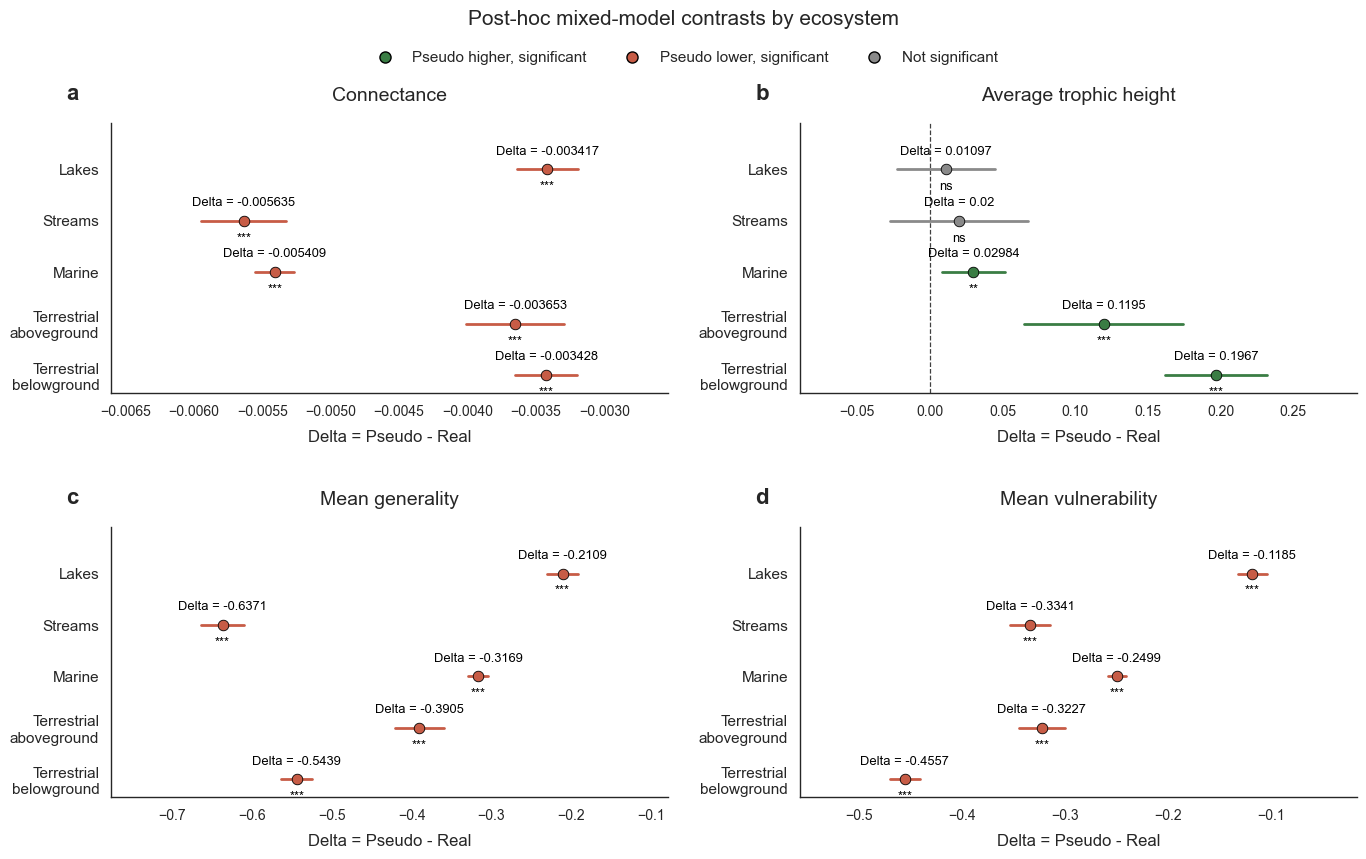

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ------------------------------------------------------------
# Locate repo root
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
)

POSTHOC_PATH = EOIN_DIR / "eoin_r_lme_posthoc_webtype_by_ecosystem_train90.csv"
posthoc = pd.read_csv(POSTHOC_PATH)

# ------------------------------------------------------------
# Labels and order
# ------------------------------------------------------------
metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

posthoc = posthoc.copy()
posthoc["Metric"] = posthoc["Metric"].astype(str)
posthoc["ecosystem"] = posthoc["ecosystem"].astype(str)

# ------------------------------------------------------------
# Values and approximate 95% CI
# DeltaPseudoMinusReal is Pseudo - Real.
# ------------------------------------------------------------
posthoc["delta"] = pd.to_numeric(posthoc["DeltaPseudoMinusReal"], errors="coerce")
posthoc["se"] = pd.to_numeric(posthoc["SE"], errors="coerce")
posthoc["p_value"] = pd.to_numeric(posthoc["p.value"], errors="coerce")

posthoc["ci_low"] = posthoc["delta"] - 1.96 * posthoc["se"]
posthoc["ci_high"] = posthoc["delta"] + 1.96 * posthoc["se"]

def significance_label(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

posthoc["sig"] = posthoc["p_value"].apply(significance_label)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
positive_color = "#3A7D44"  # pseudo higher
negative_color = "#C75C46"  # pseudo lower
ns_color = "#8A8A8A"

def point_color(row):
    if row["p_value"] >= 0.05 or pd.isna(row["p_value"]):
        return ns_color
    if row["delta"] > 0:
        return positive_color
    if row["delta"] < 0:
        return negative_color
    return ns_color

posthoc["color"] = posthoc.apply(point_color, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2), sharey=False)
axes = axes.reshape(-1)

panel_letters = list("abcd")

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    df = posthoc[posthoc["Metric"] == metric].copy()

    df["ecosystem"] = pd.Categorical(
        df["ecosystem"],
        categories=ecosystem_order,
        ordered=True,
    )
    df = df.sort_values("ecosystem")

    y_positions = np.arange(len(df))

    # horizontal CI bars + dots
    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [y, y],
            color=row["color"],
            linewidth=2.0,
            solid_capstyle="round",
            zorder=2,
        )
        ax.scatter(
            row["delta"],
            y,
            s=58,
            color=row["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )

    # zero reference line
    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )

    # x limits
    x_min = np.nanmin(df["ci_low"])
    x_max = np.nanmax(df["ci_high"])
    x_range = x_max - x_min if x_max > x_min else 1.0
    ax.set_xlim(x_min - 0.24 * x_range, x_max + 0.24 * x_range)

    # Delta labels above each dot and significance below
    y_label_offset = 0.23

    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.text(
            row["delta"],
            y - y_label_offset,
            f"Delta = {row['delta']:.4g}",
            va="bottom",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

        ax.text(
            row["delta"],
            y + y_label_offset,
            row["sig"],
            va="top",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        [ecosystem_labels.get(str(e), str(e)) for e in df["ecosystem"]],
        fontsize=11,
    )

    # More vertical breathing room at top and bottom
    ax.set_ylim(len(df) - 0.65, -0.90)

    ax.set_title(metric_labels[metric], fontsize=14, pad=16)
    ax.set_xlabel("Delta = Pseudo - Real", fontsize=12, labelpad=8)

    ax.annotate(
        panel_letters[idx],
        xy=(-0.08, 1.07),
        xycoords="axes fraction",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    sns.despine(ax=ax)
    ax.grid(False)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo higher, significant",
        markerfacecolor=positive_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo lower, significant",
        markerfacecolor=negative_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Not significant",
        markerfacecolor=ns_color,
        markeredgecolor="black",
        markersize=8,
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
    fontsize=11,
)

fig.suptitle(
    "Post-hoc mixed-model contrasts by ecosystem",
    fontsize=15,
    y=0.93,
)

plt.tight_layout(rect=[0, 0, 1, 0.91], h_pad=2.6, w_pad=2.0)

# Optional save
OUT_PATH = EOIN_DIR / "posthoc_mixed_model_delta_forest_plot_train90.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {OUT_PATH}")

plt.show()

Saved figure to: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/statistical_tests/eoin/train_ratio_60/posthoc_mixed_model_delta_forest_plot_train60.png


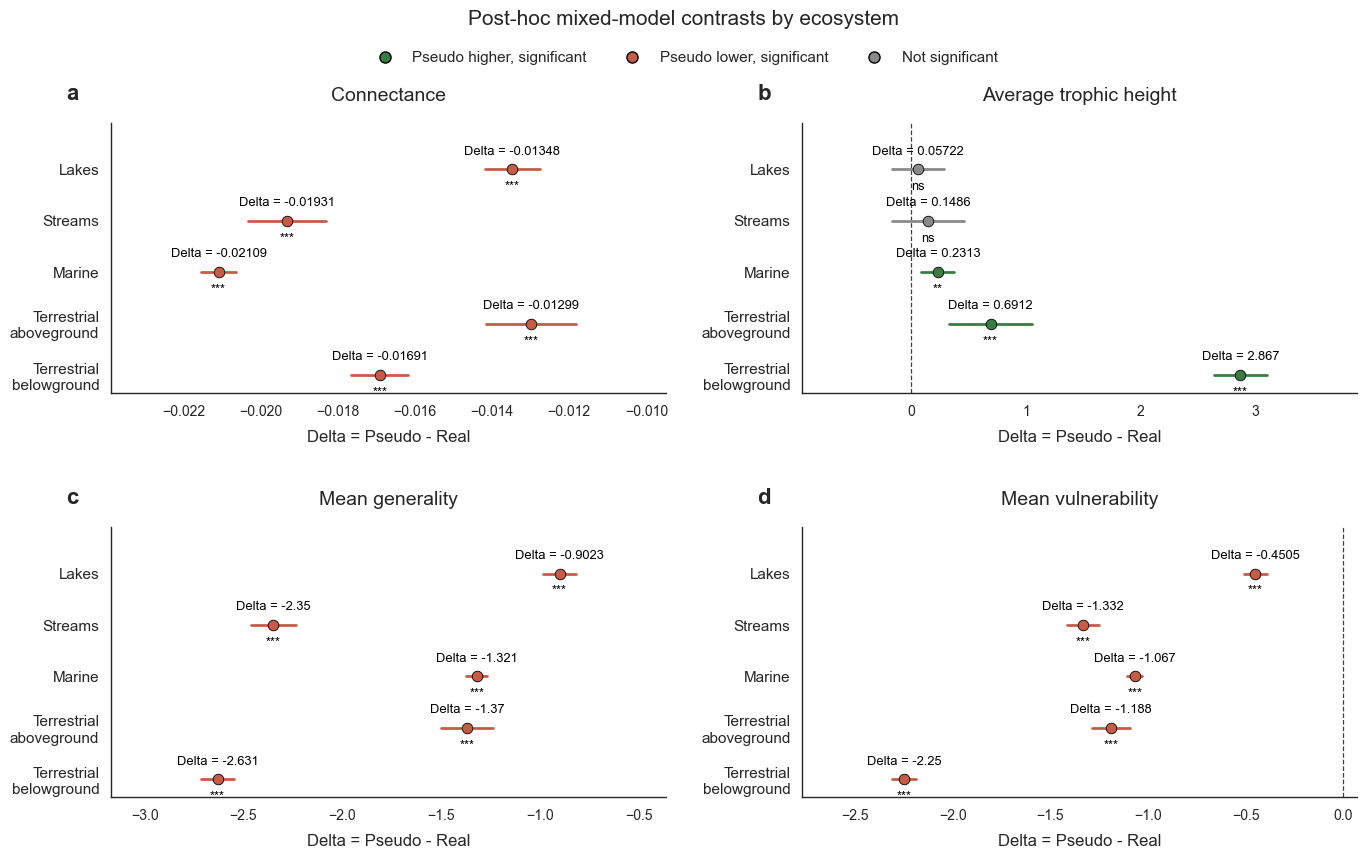

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ------------------------------------------------------------
# Locate repo root
# ------------------------------------------------------------
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root()

TRAIN_RATIO = 60

EOIN_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "statistical_tests/eoin"
    / f"train_ratio_{TRAIN_RATIO}"
)

POSTHOC_PATH = EOIN_DIR / f"eoin_r_lme_posthoc_webtype_by_ecosystem_train{TRAIN_RATIO}.csv"
posthoc = pd.read_csv(POSTHOC_PATH)

# ------------------------------------------------------------
# Labels and order
# ------------------------------------------------------------
metric_order = [
    "connectance",
    "average_trophic_height",
    "mean_generality",
    "mean_vulnerability",
]

metric_labels = {
    "connectance": "Connectance",
    "average_trophic_height": "Average trophic height",
    "mean_generality": "Mean generality",
    "mean_vulnerability": "Mean vulnerability",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

posthoc = posthoc.copy()
posthoc["Metric"] = posthoc["Metric"].astype(str)
posthoc["ecosystem"] = posthoc["ecosystem"].astype(str)

# ------------------------------------------------------------
# Values and approximate 95% CI
# DeltaPseudoMinusReal is Pseudo - Real.
# ------------------------------------------------------------
posthoc["delta"] = pd.to_numeric(posthoc["DeltaPseudoMinusReal"], errors="coerce")
posthoc["se"] = pd.to_numeric(posthoc["SE"], errors="coerce")
posthoc["p_value"] = pd.to_numeric(posthoc["p.value"], errors="coerce")

posthoc["ci_low"] = posthoc["delta"] - 1.96 * posthoc["se"]
posthoc["ci_high"] = posthoc["delta"] + 1.96 * posthoc["se"]

def significance_label(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

posthoc["sig"] = posthoc["p_value"].apply(significance_label)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
positive_color = "#3A7D44"  # pseudo higher
negative_color = "#C75C46"  # pseudo lower
ns_color = "#8A8A8A"

def point_color(row):
    if row["p_value"] >= 0.05 or pd.isna(row["p_value"]):
        return ns_color
    if row["delta"] > 0:
        return positive_color
    if row["delta"] < 0:
        return negative_color
    return ns_color

posthoc["color"] = posthoc.apply(point_color, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(13.8, 9.2), sharey=False)
axes = axes.reshape(-1)

panel_letters = list("abcd")

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    df = posthoc[posthoc["Metric"] == metric].copy()

    df["ecosystem"] = pd.Categorical(
        df["ecosystem"],
        categories=ecosystem_order,
        ordered=True,
    )
    df = df.sort_values("ecosystem")

    y_positions = np.arange(len(df))

    # horizontal CI bars + dots
    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [y, y],
            color=row["color"],
            linewidth=2.0,
            solid_capstyle="round",
            zorder=2,
        )
        ax.scatter(
            row["delta"],
            y,
            s=58,
            color=row["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )

    # zero reference line
    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
        zorder=1,
    )

    # x limits
    x_min = np.nanmin(df["ci_low"])
    x_max = np.nanmax(df["ci_high"])
    x_range = x_max - x_min if x_max > x_min else 1.0
    ax.set_xlim(x_min - 0.24 * x_range, x_max + 0.24 * x_range)

    # Delta labels above each dot and significance below
    y_label_offset = 0.23

    for y, (_, row) in zip(y_positions, df.iterrows()):
        ax.text(
            row["delta"],
            y - y_label_offset,
            f"Delta = {row['delta']:.4g}",
            va="bottom",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

        ax.text(
            row["delta"],
            y + y_label_offset,
            row["sig"],
            va="top",
            ha="center",
            fontsize=9.3,
            color="black",
            zorder=4,
            clip_on=False,
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        [ecosystem_labels.get(str(e), str(e)) for e in df["ecosystem"]],
        fontsize=11,
    )

    # More vertical breathing room at top and bottom
    ax.set_ylim(len(df) - 0.65, -0.90)

    ax.set_title(metric_labels[metric], fontsize=14, pad=16)
    ax.set_xlabel("Delta = Pseudo - Real", fontsize=12, labelpad=8)

    ax.annotate(
        panel_letters[idx],
        xy=(-0.08, 1.07),
        xycoords="axes fraction",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    sns.despine(ax=ax)
    ax.grid(False)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo higher, significant",
        markerfacecolor=positive_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Pseudo lower, significant",
        markerfacecolor=negative_color,
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Not significant",
        markerfacecolor=ns_color,
        markeredgecolor="black",
        markersize=8,
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
    fontsize=11,
)

fig.suptitle(
    "Post-hoc mixed-model contrasts by ecosystem",
    fontsize=15,
    y=0.93,
)

plt.tight_layout(rect=[0, 0, 1, 0.91], h_pad=2.6, w_pad=2.0)

# Optional save
OUT_PATH = EOIN_DIR / f"posthoc_mixed_model_delta_forest_plot_train{TRAIN_RATIO}.png"
fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {OUT_PATH}")

plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0000: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = -0.3518x + 0.9138; F1,5798 = 103.6031; R² = 0.0176; P < 0.0001; n = 5800
b) PR-AUC: y = 1.5263x + 0.3666; F1,5798 = 556.0963; R² = 0.0875; P < 0.0001; n = 5800
c) F1: y = -0.9380x + 0.8163; F1,5798 = 203.4918; R² = 0.0339; P < 0.0001; n = 5800
d) MCC: y = -1.1923x + 0.7978; F1,5798 = 295.4709; R² = 0.0485; P < 0.0001; n = 5800
e) Precision: y = -0.5025x + 0.9415; F1,5798 = 66.9666; R² = 0.0114; P < 0.0001; n = 5800
f) Recall: y = -1.1585x + 0.7591; F1,5798 = 257.8478; R² = 0.0426; P < 0.0001; n = 5800
g) TSS: y = -1.3562x + 0.7536; F1,5798 =

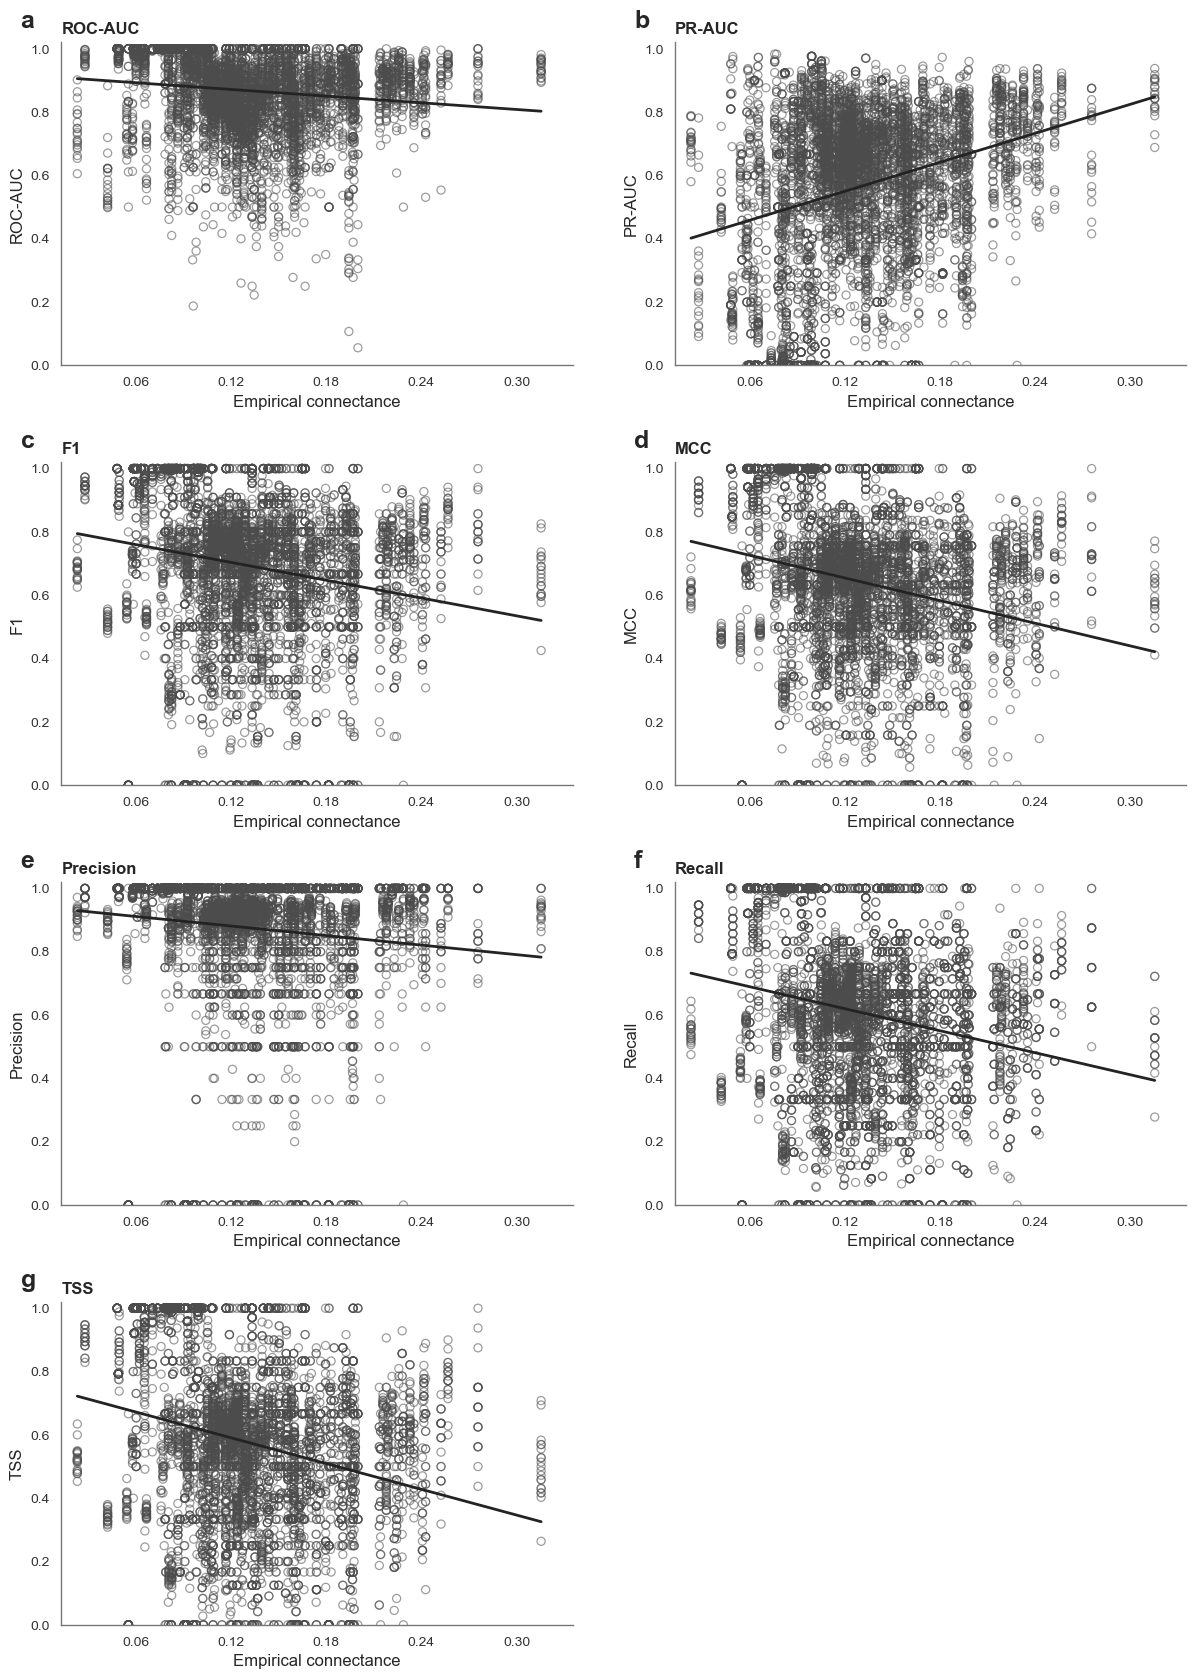

In [40]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = False

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2

POINT_COLOR = "#4C4C4C"
POINT_MARKER = "o"
POINT_SIZE = 34
POINT_ALPHA = 0.55


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO:.4f}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(colors="#333333", labelsize=10)

    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()

        ax.scatter(
            data["EmpiricalConnectanceForPlot"],
            data[metric],
            marker=POINT_MARKER,
            facecolors="none",
            edgecolors=POINT_COLOR,
            linewidths=0.9,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    fig.subplots_adjust(
        top=0.95,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    print(f"\n[INFO] Figure uses individual data points (no averaging) at TrainRatio = {TARGET_RATIO:.4f}.")
    print(f"[INFO] Total food webs represented after filtering: {total_foodwebs}")

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0000: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[FINAL] Food webs retained after filters: 290
[FINAL] Rows retained after filters: 5800

=== OLS linear regressions for caption ===
Models fitted:
  1) metric ~ log10(number of nodes)
  2) metric ~ number of nodes
Regression lines are not shown in the figure.

a) ROC-AUC [log10 nodes]: y = 0.9118 - 0.0267log10(x); F1,5798 = 31.5889; R² = 0.0054; P < 0.0001; n = 5800
a) ROC-AUC [raw nodes]: y = 0.8888 - 0.0003x; F1,5798 = 162.0088; R² = 0.0272; P < 0.0001; n = 5800

b) PR-AUC [log10 nodes]: y = 0.3592 + 0.1256log10(x); F1,5798 = 190.1380; R² = 0.0318; P < 0.0001; n = 5800
b) PR-AUC [raw nodes]: y = 0.5441 + 0.0004x; F1,5798 = 54.3556; R² = 0.0093; P < 0.0001; n = 5800

c) F1 [log10 nodes]: y = 0.5384 + 0.0923log10(x); F1,5798 = 103.6653;

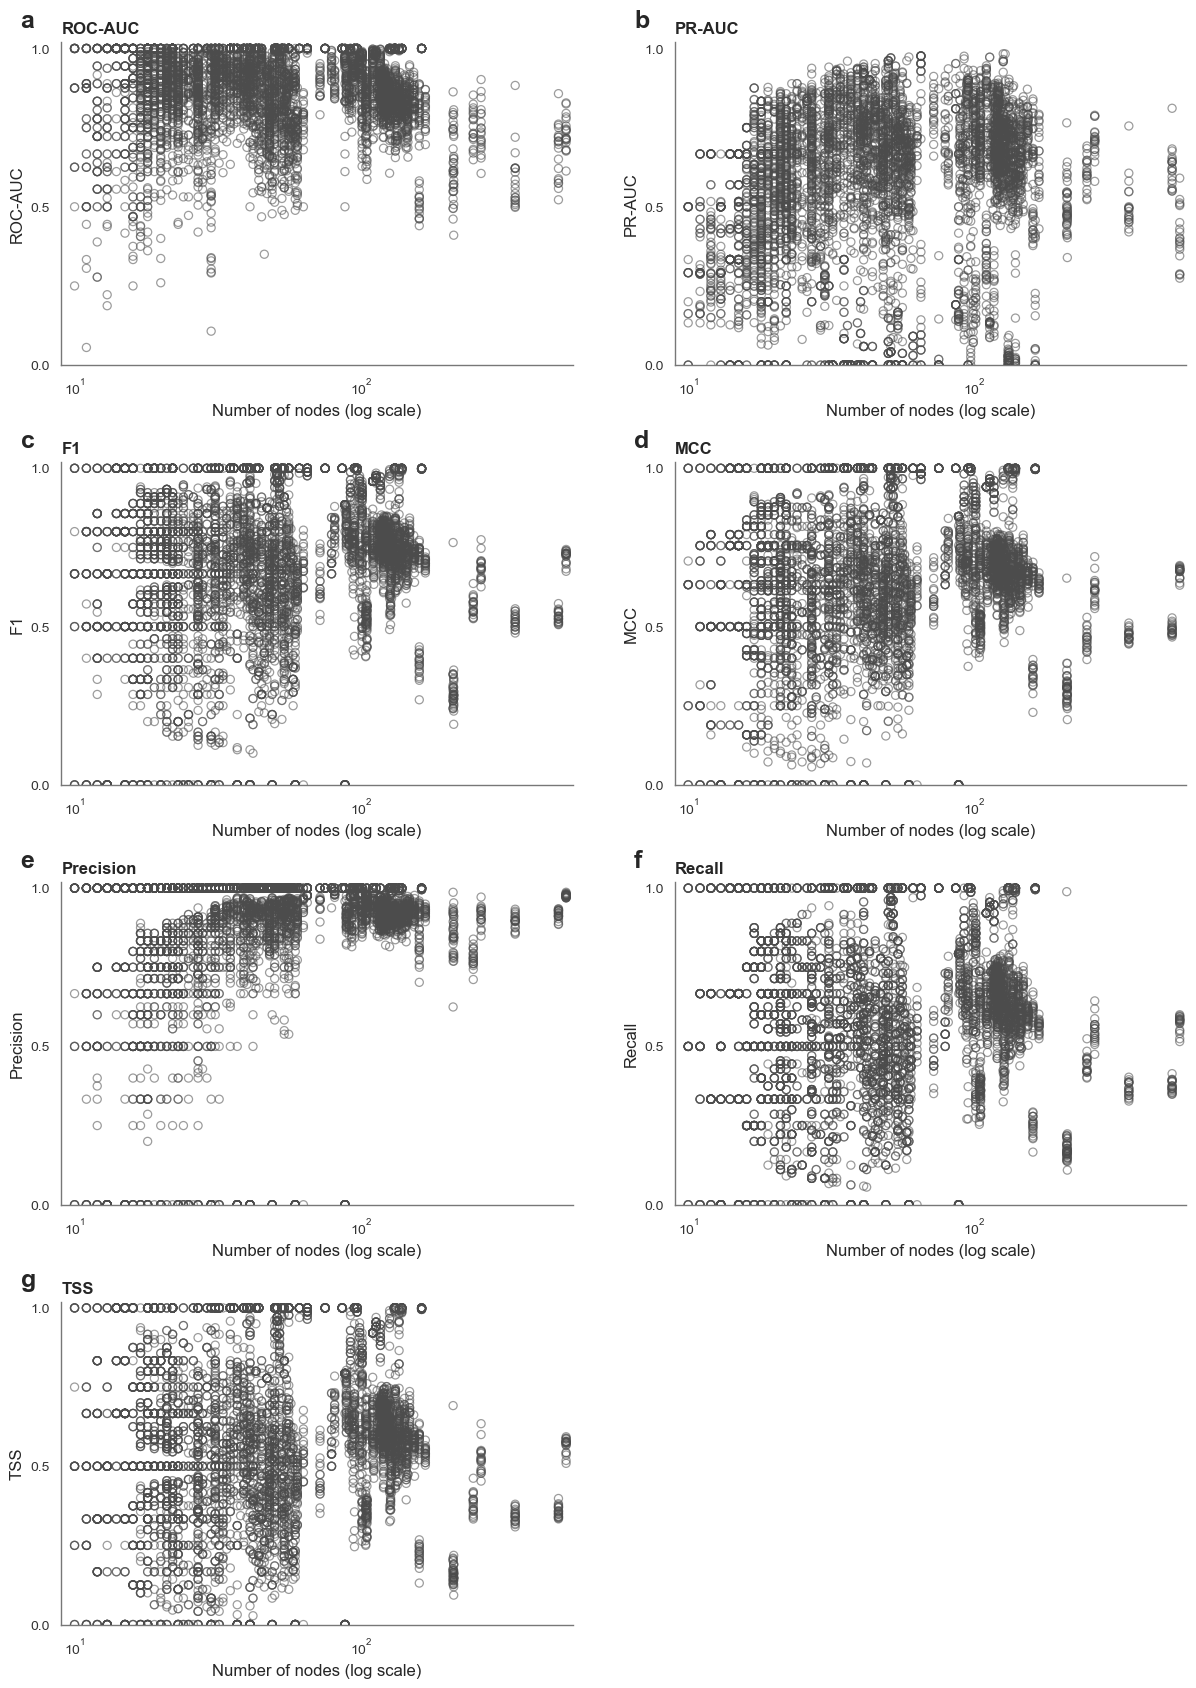

In [46]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import FormatStrFormatter, FixedLocator


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = False

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2

POINT_COLOR = "#4C4C4C"
POINT_MARKER = "o"
POINT_SIZE = 34
POINT_ALPHA = 0.55
POINT_LINEWIDTH = 0.9

X_TICKS = [10, 20, 50, 100, 200, 500]


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_log_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.4f} {sign} {abs(slope):.4f}log10(x)"


def format_raw_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.4f} {sign} {abs(slope):.4f}x"


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "Nodes",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])
    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        if "K" not in df.columns:
            raise RuntimeError("Column 'K' not found in result CSVs.")

        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO:.4f}", before, after)
    before = after

    df = df[df["Nodes"].notna()].copy()
    df = df[df["Nodes"] > 0].copy()

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[df["Nodes"] >= MIN_NODES].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "Nodes",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after filters: {df['Foodweb'].nunique()}")
    print(f"[FINAL] Rows retained after filters: {len(df)}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_logx_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
):
    """
    Fits:

        y_col ~ log10(x_col)
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = pd.to_numeric(work[x_col], errors="coerce")
    work[y_col] = pd.to_numeric(work[y_col], errors="coerce")
    work = work[(work[x_col] > 0) & work[y_col].notna()].copy()

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    work["log10_x"] = np.log10(work[x_col])

    x = work[["log10_x"]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["log10_x"]

    return {
        "intercept": intercept,
        "slope": slope,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["log10_x"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def fit_rawx_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
):
    """
    Fits:

        y_col ~ x_col
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = pd.to_numeric(work[x_col], errors="coerce")
    work[y_col] = pd.to_numeric(work[y_col], errors="coerce")
    work = work[(work[x_col] > 0) & work[y_col].notna()].copy()

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    return {
        "intercept": intercept,
        "slope": slope,
        "r_squared": model.rsquared,
        "p_value": model.pvalues[x_col],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def regression_result_text(
    panel_letter: str,
    metric_label: str,
    model_label: str,
    equation: str,
    fit: dict,
) -> str:
    p_text = format_p_value(fit["p_value"])

    return (
        f"{panel_letter}) {metric_label} [{model_label}]: "
        f"{equation}; "
        f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
        f"R² = {fit['r_squared']:.4f}; "
        f"{p_text}; "
        f"n = {fit['n']}"
    )


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Number of nodes (log scale)", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(colors="#333333", labelsize=10)

    ax.xaxis.set_major_locator(FixedLocator(X_TICKS))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


def plot_performance_vs_nodes(plot_df: pd.DataFrame):
    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = max(1.0, plot_df["Nodes"].min() * 0.90)
    x_max = plot_df["Nodes"].max() * 1.10

    if X_MAX is not None:
        x_max = min(X_MAX, x_max)

    if x_min >= x_max:
        x_min = max(1.0, plot_df["Nodes"].min())
        x_max = plot_df["Nodes"].max() * 1.10

    print("\n=== OLS linear regressions for caption ===")
    print("Models fitted:")
    print("  1) metric ~ log10(number of nodes)")
    print("  2) metric ~ number of nodes")
    print("Regression lines are not shown in the figure.\n")

    caption_log_results = []
    caption_raw_results = []

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["Nodes", metric]).copy()

        ax.scatter(
            data["Nodes"],
            data[metric],
            marker=POINT_MARKER,
            facecolors="none",
            edgecolors=POINT_COLOR,
            linewidths=POINT_LINEWIDTH,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        fit_log = fit_logx_linear_regression(data, "Nodes", metric)
        fit_raw = fit_rawx_linear_regression(data, "Nodes", metric)

        if fit_log is not None:
            equation_log = format_log_equation(
                fit_log["intercept"],
                fit_log["slope"],
            )

            result_log = regression_result_text(
                panel_letter=panel_letters[i],
                metric_label=label,
                model_label="log10 nodes",
                equation=equation_log,
                fit=fit_log,
            )

            caption_log_results.append(result_log)
            print(result_log)

        else:
            print(
                f"{panel_letters[i]}) {label} [log10 nodes]: "
                "regression not fitted; insufficient data."
            )

        if fit_raw is not None:
            equation_raw = format_raw_equation(
                fit_raw["intercept"],
                fit_raw["slope"],
            )

            result_raw = regression_result_text(
                panel_letter=panel_letters[i],
                metric_label=label,
                model_label="raw nodes",
                equation=equation_raw,
                fit=fit_raw,
            )

            caption_raw_results.append(result_raw)
            print(result_raw)

        else:
            print(
                f"{panel_letters[i]}) {label} [raw nodes]: "
                "regression not fitted; insufficient data."
            )

        print("")

        style_axes(ax, label)

        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_xscale("log")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_yticks([0.0, 0.5, 1.0])

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    fig.subplots_adjust(
        top=0.95,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    print(f"[INFO] Figure uses individual data points at TrainRatio = {TARGET_RATIO:.4f}.")
    print(f"[INFO] Total food webs represented after filtering: {total_foodwebs}")

    print("\n=== Regression results for figure caption: log10 nodes ===")
    print(
        "OLS regressions were fitted as metric ~ log10(number of nodes). "
        "Regression lines are not shown in the figure. Results: "
        + "; ".join(caption_log_results)
    )

    print("\n=== Regression results for figure caption: raw nodes ===")
    print(
        "OLS regressions were fitted as metric ~ number of nodes. "
        "Regression lines are not shown in the figure. Results: "
        + "; ".join(caption_raw_results)
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_nodes(plot_df)
plt.show()